# Temas Tratados en el Trabajo Práctico 6

* Modelado de problemas en espacios de estado.

* Algoritmos de planificación hacia adelante y hacia atrás.

* Representación y solución de problemas descritos en lenguaje STRIPS.

* Algoritmo GRAPHPLAN.

* Planificación con restricciones de tiempo y recursos.

* Caminos críticos y tiempos de relajación.

## Ejercicios Teóricos

1. ¿En qué tipo de algoritmos se basa un planificador para encontrar el mejor camino a un estado solución?

Un planificador se basa en **algoritmos de búsqueda en espacios de estados**. Cada nodo representa un estado del mundo y cada transición corresponde a una acción aplicable. Un camino desde el estado inicial hasta un estado que satisface el objetivo constituye un plan; el mejor plan es el de menor costo total según el criterio definido.

La **búsqueda de costo uniforme** expande primero el camino de menor costo acumulado y garantiza un plan óptimo en un espacio finito con costos no negativos y tratamiento adecuado de estados repetidos. **A\*** combina el costo acumulado con una estimación del costo restante: $f(n) = g(n) + h(n)$. Bajo las mismas condiciones, es óptimo si la heurística es admisible (no sobreestima el costo restante) y se reabren estados cuando se encuentra un camino mejor; con una heurística consistente no es necesario reabrirlos.


2. ¿Qué tres elementos se encuentran dentro de una acción formulada en lenguaje STRIPS? Describa brevemente qué función cumple cada uno.

Una acción en **STRIPS** contiene tres elementos:

- **Precondiciones:** condiciones que deben cumplirse en el estado actual para poder ejecutar la acción.
- **Lista de adición:** hechos que pasan a ser verdaderos después de ejecutar la acción y se agregan al estado.
- **Lista de eliminación:** hechos que dejan de ser verdaderos después de ejecutar la acción y se quitan del estado.

Si la acción $a$ es aplicable en el estado $S$, el nuevo estado es $S' = (S \setminus \mathrm{Eliminar}(a)) \cup \mathrm{Agregar}(a)$. Los hechos no afectados por la acción se mantienen.

3. Describa las ventajas y desventajas de desarrollar un algoritmo de planificación hacia adelante y hacia atrás en el espacio de estados.


**Planificación hacia adelante (progresión):** parte del estado inicial y aplica acciones cuyas precondiciones se cumplen, generando estados sucesores hasta alcanzar uno que satisfaga el objetivo.

- **Ventajas:** es sencilla de implementar y permite comprobar directamente qué acciones son ejecutables; los estados generados son alcanzables desde el estado inicial.
- **Desventajas:** puede explorar muchas acciones aplicables que no contribuyen al objetivo, lo que aumenta el factor de ramificación y el costo de búsqueda. Una buena heurística ayuda a orientar la exploración.

**Planificación hacia atrás (regresión):** parte de las metas y selecciona acciones relevantes que logren alguna de ellas sin eliminar otras metas requeridas. En cada paso reemplaza las metas logradas por las precondiciones de la acción, conservando las restantes. Termina cuando el estado inicial satisface todas las condiciones requeridas; las acciones seleccionadas se ejecutan en orden inverso al de su selección.

- **Ventajas:** concentra la búsqueda en acciones relevantes para el objetivo y puede reducir la ramificación al evitar acciones ajenas a las metas.
- **Desventajas:** requiere manejar conjuntos de submetas y sus posibles conflictos. Puede generar condiciones incompatibles o imposibles de alcanzar desde el estado inicial, y tener una ramificación elevada si muchas acciones permiten lograr las mismas metas.

4. Considere el problema de ponerse uno mismo zapatos y medias. Aplique GRAPHPLAN a este problema y muestre la solución obtenida. Muestre el plan de orden parcial que es solución e indique cuántas linealizaciones diferentes existen para el plan de orden parcial.

Plan de accipon parcial

        ┌── PonerMedia(MediaD) ──→ PonerZapato(ZapatoD,MediaD) ──┐
Inicio ─┤                                                          ├── Fin
        └── PonerMedia(MediaI) ──→ PonerZapato(ZapatoI,MediaI) ──┘

Son 6 linealizaciones diferentes 
1. MD, MI, ZD, ZI
2. MD, MI, ZI, ZD
3. MD, ZD, MI, ZI
4. MI, MD, ZD, ZI
5. MI, MD, ZI, ZD
6. MI, ZI, MD, ZD

Cuando lo ejecutamos en fast-downward el plan que devuelvió es:

(poner-media media-i)
(poner-zapato zapato-i media-i)
(poner-media media-d)
(poner-zapato zapato-d media-d)
; cost = 4 (unit cost)


5. Se requiere ensamblar una máquina cuyas piezas están identificadas con las letras A, B, C, D y E. El tiempo que se tarda en ensamblar cada pieza es:

* A: 2 semanas

* B: 1 semana

* C: 4 semanas

* D: 3 semanas

* E: 5 semanas

    El orden de ensamblaje de cada pieza requiere que:

* A esté realizado antes que C

* B esté realizado antes que C

* B esté realizado antes que D

* C esté realizado antes que E

* D esté realizado antes que E

    Con esta información:

        5.1 Arme el Plan de Orden Parcial.

        5.2 Encuentre el Camino Crítico.

        5.3 Encuentre los tiempos de relajación.

        5.4 Dibuje un diagrama temporal indicando las tareas y los tiempos de relajación encontrados.

## 5.1 
Esto dibuja los 5 círculos (A a E) con flechas mostrando quién debe terminar antes de que empiece otra pieza, siguiendo las restricciones del enunciado (A y B antes de C, B antes de D, C y D antes de E).



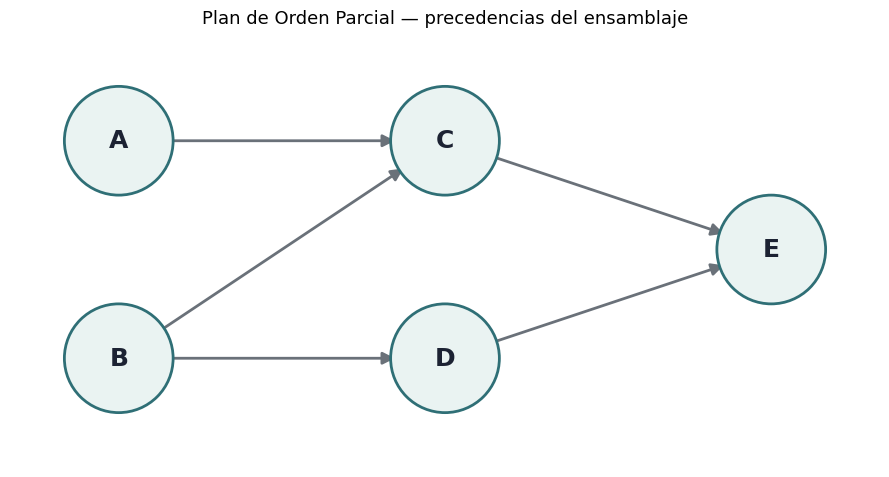

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Tareas y su posición en el diagrama
nodes = {
    'A': (1, 3),
    'B': (1, 1),
    'C': (4, 3),
    'D': (4, 1),
    'E': (7, 2),
}

# Precedencias: A<C, B<C, B<D, C<E, D<E
edges = [('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'E'), ('D', 'E')]

radius = 0.5

fig, ax = plt.subplots(figsize=(9, 5))

# Flechas primero (para que queden detrás de los círculos)
for a, b in edges:
    xa, ya = nodes[a]
    xb, yb = nodes[b]
    arrow = FancyArrowPatch((xa, ya), (xb, yb),
                             arrowstyle='-|>', mutation_scale=18,
                             color='#6a7179', lw=2,
                             shrinkA=radius*72, shrinkB=radius*72)  # deja hueco para el círculo
    ax.add_patch(arrow)

# Círculos con el nombre de cada tarea
for name, (x, y) in nodes.items():
    circle = plt.Circle((x, y), radius, facecolor='#eaf3f2',
                         edgecolor='#2f6f76', linewidth=2, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, name, ha='center', va='center',
             fontsize=18, fontweight='bold', color='#1c2233', zorder=4)

ax.set_xlim(0, 8)
ax.set_ylim(0, 4)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Plan de Orden Parcial — precedencias del ensamblaje', fontsize=13)
plt.tight_layout()
plt.show()

## 5.2
Primero se recorre de izquierda a derecha (fila de arriba) calculando los tiempos mínimos: ES = máx(EF de predecesores), EF = ES +
duración. Después se recorre de derecha a izquierda (fila de abajo) calculando los tiempos máximos: LF = mín(LS de sucesores), LS = LF
duración.



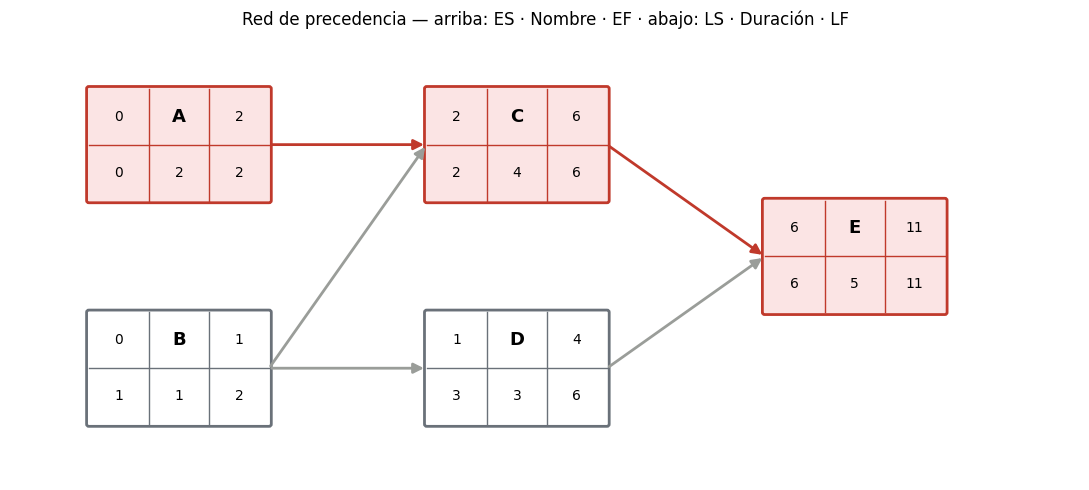

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

nodes = {
    'A': {'es': 0, 'ef': 2,  'ls': 0, 'lf': 2,  'dur': 2, 'pos': (1, 3)},
    'B': {'es': 0, 'ef': 1,  'ls': 1, 'lf': 2,  'dur': 1, 'pos': (1, 1)},
    'C': {'es': 2, 'ef': 6,  'ls': 2, 'lf': 6,  'dur': 4, 'pos': (4, 3)},
    'D': {'es': 1, 'ef': 4,  'ls': 3, 'lf': 6,  'dur': 3, 'pos': (4, 1)},
    'E': {'es': 6, 'ef': 11, 'ls': 6, 'lf': 11, 'dur': 5, 'pos': (7, 2)},
}
edges = [('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'E'), ('D', 'E')]
critical = {'A', 'C', 'E'}

fig, ax = plt.subplots(figsize=(11, 5))
box_w, box_h = 1.6, 1.0

def draw_node(ax, name, d):
    x, y = d['pos']
    color = '#c0392b' if name in critical else '#6a7179'
    face = '#fbe4e4' if name in critical else '#ffffff'
    rect = mpatches.FancyBboxPatch((x - box_w/2, y - box_h/2), box_w, box_h,
                                    boxstyle="round,pad=0.02", linewidth=2,
                                    edgecolor=color, facecolor=face)
    ax.add_patch(rect)
    ax.plot([x - box_w/2, x + box_w/2], [y, y], color=color, lw=1)
    ax.plot([x - box_w/6]*2, [y - box_h/2, y + box_h/2], color=color, lw=1)
    ax.plot([x + box_w/6]*2, [y - box_h/2, y + box_h/2], color=color, lw=1)
    ax.text(x - box_w/3, y + box_h/4, d['es'],  ha='center', va='center', fontsize=10)
    ax.text(x,           y + box_h/4, name,     ha='center', va='center', fontsize=13, fontweight='bold')
    ax.text(x + box_w/3, y + box_h/4, d['ef'],  ha='center', va='center', fontsize=10)
    ax.text(x - box_w/3, y - box_h/4, d['ls'],  ha='center', va='center', fontsize=10)
    ax.text(x,           y - box_h/4, d['dur'], ha='center', va='center', fontsize=10)
    ax.text(x + box_w/3, y - box_h/4, d['lf'],  ha='center', va='center', fontsize=10)

for name, d in nodes.items():
    draw_node(ax, name, d)

for a, b in edges:
    xa, ya = nodes[a]['pos']
    xb, yb = nodes[b]['pos']
    color = '#c0392b' if (a in critical and b in critical) else '#9a9d99'
    arrow = FancyArrowPatch((xa + box_w/2, ya), (xb - box_w/2, yb),
                             arrowstyle='-|>', mutation_scale=15, color=color, lw=2)
    ax.add_patch(arrow)

ax.set_xlim(-0.5, 9)
ax.set_ylim(0, 4)
ax.axis('off')
ax.set_title('Red de precedencia — arriba: ES · Nombre · EF · abajo: LS · Duración · LF')
plt.tight_layout()
plt.show()

## 5.3
En B y D — donde el camino se separa del crítico (rojo) — esas dos pasadas ya no coinciden: la diferencia es la holguraH. olgura = LS ES
= LF EF

## 5.4

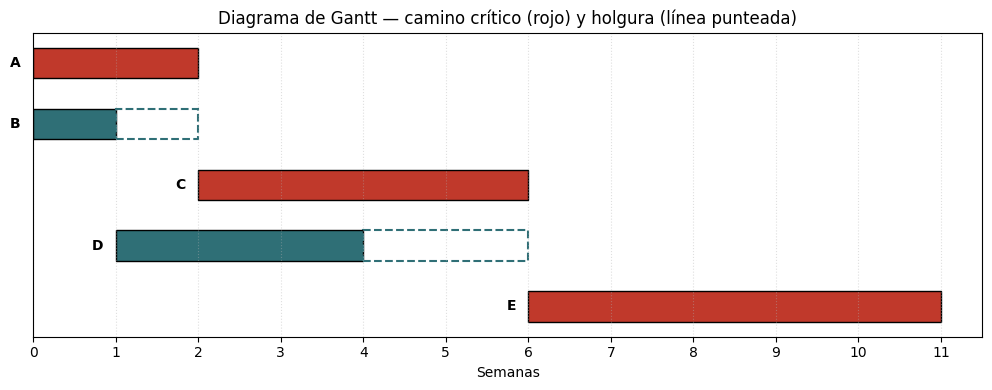

In [1]:
import matplotlib.pyplot as plt

tasks = ['A', 'B', 'C', 'D', 'E']
es = {'A': 0, 'B': 0, 'C': 2, 'D': 1, 'E': 6}   # inicio mínimo
ef = {'A': 2, 'B': 1, 'C': 6, 'D': 4, 'E': 11}  # fin mínimo
lf = {'A': 2, 'B': 2, 'C': 6, 'D': 6, 'E': 11}  # fin máximo
critical = {'A', 'C', 'E'}

fig, ax = plt.subplots(figsize=(10, 4))

for i, t in enumerate(tasks):
    y = len(tasks) - i - 1
    dur = ef[t] - es[t]
    slack = lf[t] - ef[t]
    color = '#c0392b' if t in critical else '#2f6f76'

    ax.barh(y, dur, left=es[t], height=0.5, color=color, edgecolor='black')
    if slack > 0:
        ax.barh(y, slack, left=ef[t], height=0.5, facecolor='none',
                edgecolor=color, linestyle='--', linewidth=1.5)
    ax.text(es[t] - 0.15, y, t, va='center', ha='right', fontweight='bold')

ax.set_xlim(0, 11.5)
ax.set_ylim(-0.5, len(tasks) - 0.5)
ax.set_yticks([])
ax.set_xticks(range(0, 12))
ax.set_xlabel('Semanas')
ax.set_title('Diagrama de Gantt — camino crítico (rojo) y holgura (línea punteada)')
ax.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

## Ejercicios de Implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

6. Suponga que tiene un robot de oficina capaz de moverse y tomar y depositar objetos. El robot solo puede tener un objeto a la vez, pero puede conseguir una *caja* en la que depositar varios objetos. Suponga que programa al robot para *ir a la tienda* a comprarle un *café* y en el camino de vuelta tome una *carta* del *buzón* de la oficina para para que se la traiga junto con el café. Describa en lenguaje STRIPS:

        6.1 El dominio del robot (nombre, predicados y acciones que puede hacer el robot).

        6.2 El problema que se quiere resolver (estado inicial, estado objetivo y objetos del mundo representados).

        6.3 Introduzca el código desarrollado en los puntos anteriores en el [planificador online](http://lcas.lincoln.ac.uk/fast-downward/) y obtenga el plan de acción que tomará el robot para cumplir lo solicitado.

6.1 DOMINIO DEL ROBOT

CASO A

In [ ]:

    (define (domain robot-oficina) ;Nombre
  (:requirements :strips :typing)

  ;objetos
  (:types lugar objeto caja)

  (:predicates ;estados que pueden ser V/F
    (robot-en ?l - lugar) ;el robot esta en el lugar ?l
    (mano-libre)                ;la mano del robot esta libre
    (sosteniendo ?o - objeto)   ;el robot sostieneel objeto ?o en la mano 
    (objeto-en ?o - objeto ?l - lugar) ;el objeto ?o esta en el lugar ?l
    (caja-en ?c - caja ?l - lugar) ;la caja ?c esta en el lugar ?l
    (robot-tiene-caja ?c - caja) ;el robot esta cargando la caja ?c
    (dentro-caja ?o - objeto ?c - caja) ; el objeto ?o esta guardado dentro de la caja ?c
  )

    ;moverse de un lugar a otro
  (:action mover 
    :parameters (?desde - lugar ?hasta - lugar) ;aca las variables son el lugar de salida y de llegada
    :precondition (robot-en ?desde)
    :effect (and (robot-en ?hasta) (not (robot-en ?desde)))
  )

    ;tomar un objeto cuando la mano esta libre
  (:action tomar-objeto
    :parameters (?o - objeto ?l - lugar) ;indica que variables actuan en la accion (objeto+lugar)
    :precondition (and (robot-en ?l) (objeto-en ?o ?l) (mano-libre)) ;si esto no es V (mano ocupada) el planificador no permitira la accion
    :effect (and (sosteniendo ?o) (not (objeto-en ?o ?l)) (not (mano-libre))) ;como cambia el mundo despues de que la accion se ejecuta con exito
  )   ;mundo actual-> (sosteniendo ?o) pasa a ser V (el robot tiene algo en la mano); (not (objeto-en ?o ?l))-> el objeto ya no esta tirado en ese lugar ; (not (mano-libre))-> predicado de manos libre F

     ; dejar en el lugar actual el objeto que se sostiene en la mano
  (:action dejar-objeto
    :parameters (?o - objeto ?l - lugar)
    :precondition (and (robot-en ?l) (sosteniendo ?o))
    :effect (and (objeto-en ?o ?l) (mano-libre) (not (sosteniendo ?o)))
  )

    ;tomar caja que esta en el lugar actual
  (:action tomar-caja
    :parameters (?c - caja ?l - lugar)
    :precondition (and (robot-en ?l) (caja-en ?c ?l))
    :effect (and (robot-tiene-caja ?c) (not (caja-en ?c ?l)))
  )

    ;dejar la caja que se esta cargando en el lugar actual
  (:action dejar-caja
    :parameters (?c - caja ?l - lugar)
    :precondition (and (robot-en ?l) (robot-tiene-caja ?c))
    :effect (and (caja-en ?c ?l) (not (robot-tiene-caja ?c)))
  )

    ;guardar dentro de la caja el objeto que se sostiene en la mano
    ;(asi la mano queda libre para tomar otra cosa, aunque el objeto sigue "con" el robot)
  (:action guardar-en-caja
    :parameters (?o - objeto ?c - caja)
    :precondition (and (sosteniendo ?o) (robot-tiene-caja ?c))
    :effect (and (dentro-caja ?o ?c) (mano-libre) (not (sosteniendo ?o)))
  )

    ;sacar de la caja un objeto y tomarlo con la mano
  (:action sacar-de-caja
    :parameters (?o - objeto ?c - caja)
    :precondition (and (dentro-caja ?o ?c) (robot-tiene-caja ?c) (mano-libre))
    :effect (and (sosteniendo ?o) (not (dentro-caja ?o ?c)) (not (mano-libre)))
  )
)


CASO B

In [ ]:
(define (domain robot-oficina)
  (:requirements :strips :typing :action-costs)
  (:types lugar objeto caja)

  (:predicates
    (robot-en ?l - lugar)
    (mano-libre)
    (sosteniendo ?o - objeto)
    (objeto-en ?o - objeto ?l - lugar)
    (caja-en ?c - caja ?l - lugar)
    (robot-tiene-caja ?c - caja)
    (dentro-caja ?o - objeto ?c - caja)
    (conectado ?a - lugar ?b - lugar)   ; ?a y ?b están unidos por un camino directo
  )

  (:functions
    (total-cost) - number
    (distancia ?a - lugar ?b - lugar) - number
  )

  ; Moverse: solo entre lugares conectados; el costo depende de la distancia
  (:action mover
    :parameters (?desde - lugar ?hasta - lugar)
    :precondition (and (robot-en ?desde) (conectado ?desde ?hasta))
    :effect (and
              (robot-en ?hasta)
              (not (robot-en ?desde))
              (increase (total-cost) (distancia ?desde ?hasta))
            )
  )

  (:action tomar-objeto
    :parameters (?o - objeto ?l - lugar)
    :precondition (and (robot-en ?l) (objeto-en ?o ?l) (mano-libre))
    :effect (and (sosteniendo ?o) (not (objeto-en ?o ?l)) (not (mano-libre)))
  )

  (:action dejar-objeto
    :parameters (?o - objeto ?l - lugar)
    :precondition (and (robot-en ?l) (sosteniendo ?o))
    :effect (and (objeto-en ?o ?l) (mano-libre) (not (sosteniendo ?o)))
  )

  (:action tomar-caja
    :parameters (?c - caja ?l - lugar)
    :precondition (and (robot-en ?l) (caja-en ?c ?l))
    :effect (and (robot-tiene-caja ?c) (not (caja-en ?c ?l)))
  )

  (:action dejar-caja
    :parameters (?c - caja ?l - lugar)
    :precondition (and (robot-en ?l) (robot-tiene-caja ?c))
    :effect (and (caja-en ?c ?l) (not (robot-tiene-caja ?c)))
  )

  (:action guardar-en-caja
    :parameters (?o - objeto ?c - caja)
    :precondition (and (sosteniendo ?o) (robot-tiene-caja ?c))
    :effect (and (dentro-caja ?o ?c) (mano-libre) (not (sosteniendo ?o)))
  )

  (:action sacar-de-caja
    :parameters (?o - objeto ?c - caja)
    :precondition (and (dentro-caja ?o ?c) (robot-tiene-caja ?c) (mano-libre))
    :effect (and (sosteniendo ?o) (not (dentro-caja ?o ?c)) (not (mano-libre)))
  )
)

6.2 PROBLEMA

CASO A

In [ ]:
(define (problem llevar-cafe-y-carta)
  (:domain robot-oficina)

  ;objetos
  (:objects
    oficina tienda buzon - lugar   ; los tres lugares del escenario
    cafe carta - objeto            ; los dos objetos a transportar
    caja1 - caja                   ; la caja disponible para cargar varios objetos
  )

  ;estado inicial
  (:init
    (robot-en oficina)        ; el robot arranca en la oficina
    (mano-libre)               ; con la mano vacia
    (caja-en caja1 oficina)    ; la caja esta disponible en la oficina
    (objeto-en cafe tienda)    ; el cafe esta en la tienda
    (objeto-en carta buzon)    ; la carta esta en el buzon
  )

  ; estado final
  (:goal
    (and
      (robot-en oficina)       ; el robot debe volver a la oficina
      (objeto-en cafe oficina) ; con el cafe depositado en la oficina
      (objeto-en carta oficina) ; y con la carta depositada en la oficina
    )
  )
)

CASO B

In [ ]:
(define (problem llevar-cafe-y-carta)
  (:domain robot-oficina)
  (:objects
    oficina buzon tienda - lugar
    cafe carta - objeto
    caja1 - caja
  )
  (:init
    (robot-en oficina)
    (mano-libre)
    (caja-en caja1 oficina)
    (objeto-en cafe tienda)
    (objeto-en carta buzon)

    ; ruta lineal: oficina - buzon - tienda (no hay atajo oficina-tienda)
    (conectado oficina buzon)
    (conectado buzon oficina)
    (conectado buzon tienda)
    (conectado tienda buzon)

    ; costos de moverse (representan distancia/tiempo)
    (= (distancia oficina buzon) 3)
    (= (distancia buzon oficina) 3)
    (= (distancia buzon tienda) 4)
    (= (distancia tienda buzon) 4)

    (= (total-cost) 0)
  )
  (:goal
    (and
      (robot-en oficina)
      (objeto-en cafe oficina)
      (objeto-en carta oficina)
    )
  )
  (:metric minimize (total-cost))
)

6.3 PLAN DE ACCION

CASO A
Se obtuvo un plan donde no se usa la caja, en vez de hacer un solo viaje llevando el cafe y la carta juntos, el robot hace dos viajes separados primero va al buzon y vuelve con la carta, despues va a la tienda y vuelve con el cafe.
Esto paso porque el objetivo A solo pide que al final el cafe y la carta esten en la oficiona, no exige que sea en un solo viaje. Cada accion cuenta lo mismo entonces el planificador prefirio un camino con menos acciones separando viajes (8 ACCIONES)

CASO B
Para forzar que el robot pase por el buzon volviendo de la tienda, se utilizo uno ruta lineal (oficina->buzon->tienda) no hay conexion directa oficina->tienda
Ademas, por sujerencia de la IA se implemento lo siguiente:
"El movimiento cuesta caro, manipular objetos es barato: agregue costos de acción (:action-costs), donde cada mover tiene un costo (representa distancia/tiempo) y las acciones de tomar/dejar/guardar cuestan 0. Esto refleja que ir y volver dos veces es más "caro" que cargar todo en la caja en un solo viaje."
Ocurrio que el backend online no soporta bien :action-costs ni :functions. Al agregar el costo de distancia, el traductor se cuelga y termina timeouteando. Es una limitación conocida de esa herramienta, que solo maneja bien STRIPS "puro" con costo unitario.
Se agrega a diapositivas el plan optimo esperado por el CASO B

CONCLUSION-> Al ejecutar el problema en el planificador online, el plan obtenido (costo 8) resuelve el objetivo llevando el café y la carta a la oficina mediante dos viajes independientes, sin utilizar la caja.
Esto pone de manifiesto una característica propia de STRIPS clásico: al no incorporar costos diferenciados entre acciones, el planificador evalúa únicamente si el estado objetivo se alcanza, y no distingue entre estrategias que impliquen distinto número de desplazamientos si estos poseen igual costo unitario. En consecuencia, el plan hallado —aunque válido y óptimo dentro de las reglas del dominio— no refleja necesariamente la interpretación estricta del enunciado (traer ambos objetos en un mismo recorrido).


PROMPT
Hola. Necesito que me ayudes a resolver un ejercicio de planificación en STRIPS para un trabajo práctico de la facultad. Te voy a explicar la situación para que armemos juntos la solución paso a paso.

El escenario es el siguiente: tenemos un robot de oficina que se puede mover, tomar y depositar objetos. La particularidad es que el robot solo puede llevar un objeto a la vez en la mano, pero puede conseguir una caja en la que meter varios objetos
La misión que le tengo que programar al robot consiste en: ir a la oficina de la tienda a comprar un café, y de regreso pasar por el buzón de la oficina para buscar una carta, de modo que al final el robot traiga ambas cosas (el café y la carta) a la oficina

Para resolverlo, necesito que estructures la respuesta en tres partes según nos pide la consigna:

1. El dominio del robot: Define el nombre, todos los predicados necesarios (posiciones, estados de las manos, caja, etc.) y las acciones en formato STRIPS (con sus precondiciones y efectos)
2. El problema: Detalla los objetos del mundo, el estado inicial y el estado objetivo que queremos alcanzar
3. Código y plan: Traduce el dominio y el problema a la sintaxis PDDL/STRIPS compatible con el planificador online de Fast Downward, y muéstrame cuál sería el plan de acción resultante

Por favor, explícame bien cada sección para que pueda entender el razonamiento detrás de los predicados y las acciones.


# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)